In [2]:
# ── Step 1: Upload your CSV file ─────────────────────────
from google.colab import files
print("Please upload customer_churn_nn.csv")
uploaded = files.upload()

# ── Step 2: Install any missing libraries ─────────────────
import subprocess
subprocess.run(["pip", "install", "--quiet",
                 "tensorflow", "scikit-learn",
                 "pandas", "matplotlib", "seaborn"])

# ── Step 3: Create results folder ────────────────────────
import os
os.makedirs('results', exist_ok=True)
print("✅ Setup complete! Run the next cells in order.")

Please upload customer_churn_nn.csv


Saving customer_churn_nn.csv to customer_churn_nn.csv
✅ Setup complete! Run the next cells in order.


Shape: 2000 rows × 17 columns

Numerical : ['tenure_months', 'monthly_charges_inr', 'avg_login_days_per_month', 'support_tickets_last_90_days', 'payment_delay_days', 'data_usage_gb', 'satisfaction_score', 'last_complaint_days_ago', 'discount_percent', 'autopay_enabled', 'referral_count']
Categorical: ['customer_id', 'region', 'plan_type', 'contract_type', 'payment_method']

Missing values:
customer_id                     0
region                          0
plan_type                       0
contract_type                   0
payment_method                  0
tenure_months                   0
monthly_charges_inr             0
avg_login_days_per_month        0
support_tickets_last_90_days    0
payment_delay_days              0
data_usage_gb                   0
satisfaction_score              0
last_complaint_days_ago         0
discount_percent                0
autopay_enabled                 0
referral_count                  0
churn                           0
dtype: int64

Statistical Sum

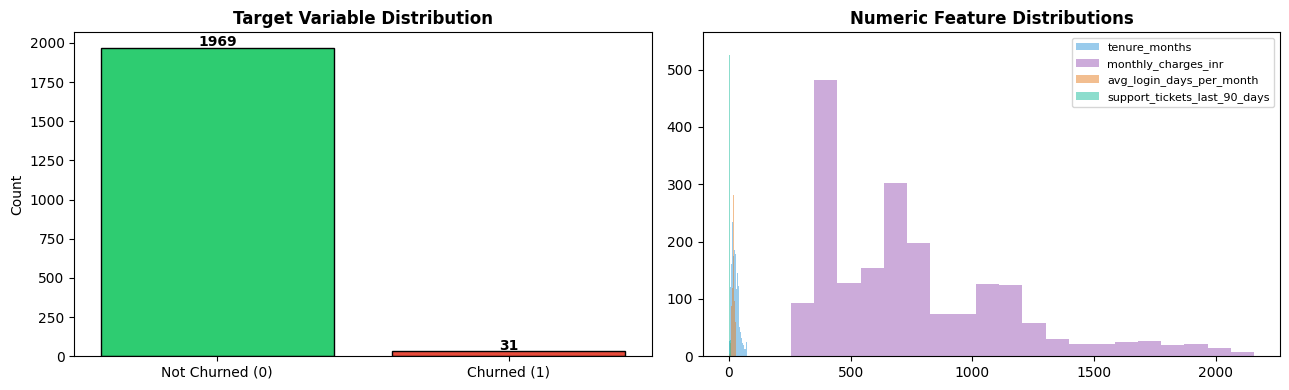

✅ Task 1 complete


In [4]:
##TASK 1
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os, warnings, tensorflow as tf
warnings.filterwarnings('ignore')
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

# ── Load ──────────────────────────────────────────────────
df = pd.read_csv('customer_churn_nn.csv')
print(f"Shape: {df.shape[0]} rows × {df.shape[1]} columns")
print(f"\nNumerical : {df.select_dtypes(include='number').columns.drop('churn').tolist()}")
print(f"Categorical: {df.select_dtypes(include='object').columns.tolist()}")

# ── Missing values ────────────────────────────────────────
print("\nMissing values:")
print(df.isnull().sum())

# ── Statistical summary ───────────────────────────────────
print("\nStatistical Summary:")
print(df.describe())

# ── Target distribution ───────────────────────────────────
churn_counts = df['churn'].value_counts()
print(f"\nChurn rate: {churn_counts[1]/len(df)*100:.2f}% — imbalanced!")

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

bars = axes[0].bar(['Not Churned (0)', 'Churned (1)'],
                 churn_counts.values,
                 color=['#2ecc71', '#e74c3c'], edgecolor='black')
axes[0].set_title('Target Variable Distribution', fontweight='bold')
axes[0].set_ylabel('Count')
for bar, val in zip(bars, churn_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 10, str(val), ha='center', fontweight='bold')

num_cols = df.select_dtypes(include='number').drop(columns=['churn']).columns[:4]
colors = ['#3498db', '#9b59b6', '#e67e22', '#1abc9c']
for col, c in zip(num_cols, colors):
    axes[1].hist(df[col], bins=20, alpha=0.5, label=col, color=c)
axes[1].set_title('Numeric Feature Distributions', fontweight='bold')
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.savefig('results/task1_exploration.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Task 1 complete")

In [5]:
##TASK 2
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.utils.class_weight import compute_class_weight

# ── Drop ID column ────────────────────────────────────────
df_proc = df.drop(columns=['customer_id']).copy()

# ── Encode categorical columns ────────────────────────────
cat_cols = df_proc.select_dtypes(include='object').columns.tolist()
le = LabelEncoder()
for col in cat_cols:
    df_proc[col] = le.fit_transform(df_proc[col])
    print(f"  Encoded: {col}")

# ── Split features and target ─────────────────────────────
X = df_proc.drop(columns=['churn'])
y = df_proc['churn']

# ── Stratified 80/20 split ────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# ── Standard scaling ──────────────────────────────────────
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

# ── Class weights ─────────────────────────────────────────
cw = compute_class_weight('balanced',
                          classes=np.array([0, 1]),
                          y=y_train.values)
class_weight = {0: cw[0], 1: cw[1]}

print(f"\nTrain: {X_train_sc.shape} | Test: {X_test_sc.shape}")
print(f"Class weights: {class_weight}")
print("✅ Task 2 complete")

  Encoded: region
  Encoded: plan_type
  Encoded: contract_type
  Encoded: payment_method

Train: (1600, 15) | Test: (400, 15)
Class weights: {0: np.float64(0.5079365079365079), 1: np.float64(32.0)}
✅ Task 2 complete


In [7]:
##TASK 3
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam

tf.random.set_seed(42)
np.random.seed(42)

# ── Reusable model builder ────────────────────────────────
def build_model(hidden_layers=[64, 32], activation='relu',
                lr=0.001, dropout=0.3, input_dim=15):
    model = Sequential()

    # First hidden layer
    model.add(Dense(hidden_layers[0], activation=activation,
                    input_shape=(input_dim,)))
    model.add(Dropout(dropout))

    # Additional hidden layers
    for units in hidden_layers[1:]:
        model.add(Dense(units, activation=activation))
        model.add(Dropout(dropout))

    # Output layer — sigmoid for binary classification
    model.add(Dense(1, activation='sigmoid'))

    model.compile(
        optimizer=Adam(learning_rate=lr),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    return model

# ── Build baseline model ──────────────────────────────────
# Input(15)→Dense(64,ReLU)→Dropout(0.3)→Dense(32,ReLU)→Dropout(0.3)→Dense(1,Sigmoid)
baseline = build_model(input_dim=X_train_sc.shape[1])
baseline.summary()
print("✅ Task 3 complete")

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 64)             │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,137 (12.25 KB)

 Trainable params: 3,137 (12.25 KB)

 Non-trainable params: 0 (0.00 B)

✅ Task 3 complete


Epoch 1/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7906 - loss: 0.7129 - val_accuracy: 0.7500 - val_loss: 0.5380
Epoch 2/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7367 - loss: 0.6615 - val_accuracy: 0.6344 - val_loss: 0.6111
Epoch 3/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6844 - loss: 0.6070 - val_accuracy: 0.6062 - val_loss: 0.6358
Epoch 4/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.6547 - loss: 0.5478 - val_accuracy: 0.6281 - val_loss: 0.6144
Epoch 5/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6930 - loss: 0.5529 - val_accuracy: 0.6812 - val_loss: 0.5684
Epoch 6/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7195 - loss: 0.5135 - val_accuracy: 0.6844 - val_loss: 0.5657
Epoch 7/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7305 - loss: 0.5109 - val_accuracy: 0.7094 - val_loss: 0.5422
Epoch 8/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7469 - loss: 0.5053 - val_accuracy: 0.7250 - 

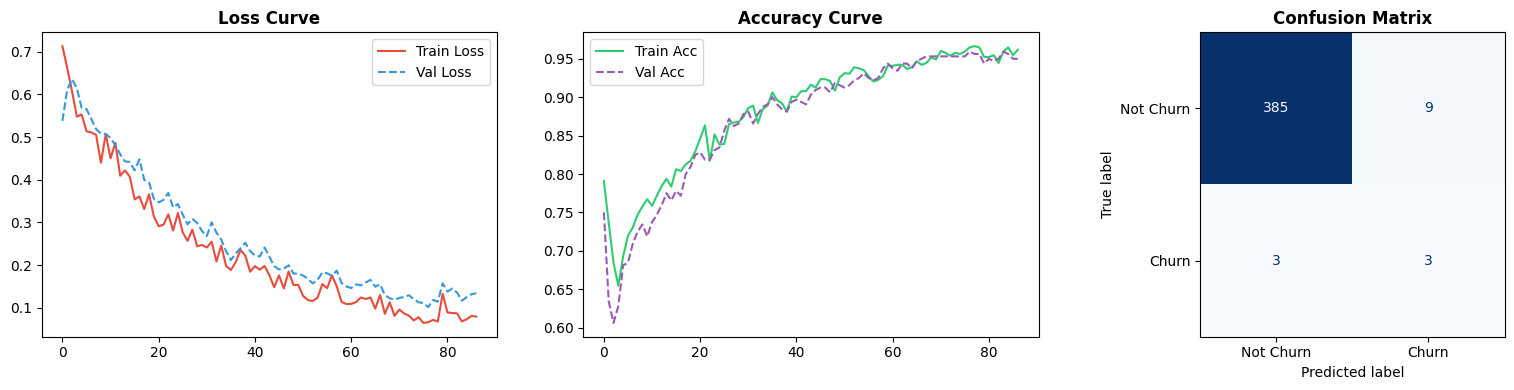

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Task 4 complete — evaluation_outputs.png downloaded


In [9]:
##TASK 4
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import (confusion_matrix, classification_report,
                               ConfusionMatrixDisplay)

# ── Train ─────────────────────────────────────────────────
es = EarlyStopping(patience=10, restore_best_weights=True,
                   monitor='val_loss')
history = baseline.fit(
    X_train_sc, y_train,
    epochs=100, batch_size=32,
    validation_split=0.2,
    class_weight=class_weight,
    callbacks=[es],
    verbose=1
)

# ── Evaluate ──────────────────────────────────────────────
train_loss, train_acc = baseline.evaluate(X_train_sc, y_train, verbose=0)
test_loss,  test_acc  = baseline.evaluate(X_test_sc,  y_test,  verbose=0)
print(f"Train → Acc: {train_acc:.4f} | Loss: {train_loss:.4f}")
print(f"Test  → Acc: {test_acc:.4f}  | Loss: {test_loss:.4f}")

y_pred = (baseline.predict(X_test_sc, verbose=0).flatten() >= 0.5).astype(int)
print("\nClassification Report:")
print(classification_report(y_test, y_pred,
      target_names=['Not Churn', 'Churn']))

# ── Plot loss curves + confusion matrix ───────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].plot(history.history['loss'],     label='Train Loss',  color='#e74c3c')
axes[0].plot(history.history['val_loss'], label='Val Loss',    color='#3498db', linestyle='--')
axes[0].set_title('Loss Curve', fontweight='bold'); axes[0].legend()

axes[1].plot(history.history['accuracy'],     label='Train Acc', color='#2ecc71')
axes[1].plot(history.history['val_accuracy'], label='Val Acc',   color='#9b59b6', linestyle='--')
axes[1].set_title('Accuracy Curve', fontweight='bold'); axes[1].legend()

cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=['Not Churn', 'Churn']).plot(
    ax=axes[2], colorbar=False, cmap='Blues')
axes[2].set_title('Confusion Matrix', fontweight='bold')

plt.tight_layout()
plt.savefig('results/evaluation_outputs.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Download to your PC ───────────────────────────────────
from google.colab import files
files.download('results/evaluation_outputs.png')
print("✅ Task 4 complete — evaluation_outputs.png downloaded")

  Baseline               → Test Acc:0.9750  F1:0.0000  Recall:0.0000
  Deeper Network         → Test Acc:0.9475  F1:0.0870  Recall:0.1667
  Higher LR 0.01         → Test Acc:0.9300  F1:0.2222  Recall:0.6667
  Lower LR 1e-4          → Test Acc:0.9125  F1:0.1026  Recall:0.3333
  Larger Batch 128       → Test Acc:0.8975  F1:0.1961  Recall:0.8333
  Tanh Activation        → Test Acc:0.7250  F1:0.0833  Recall:0.8333
  Wider + Leaky          → Test Acc:0.9550  F1:0.1818  Recall:0.3333


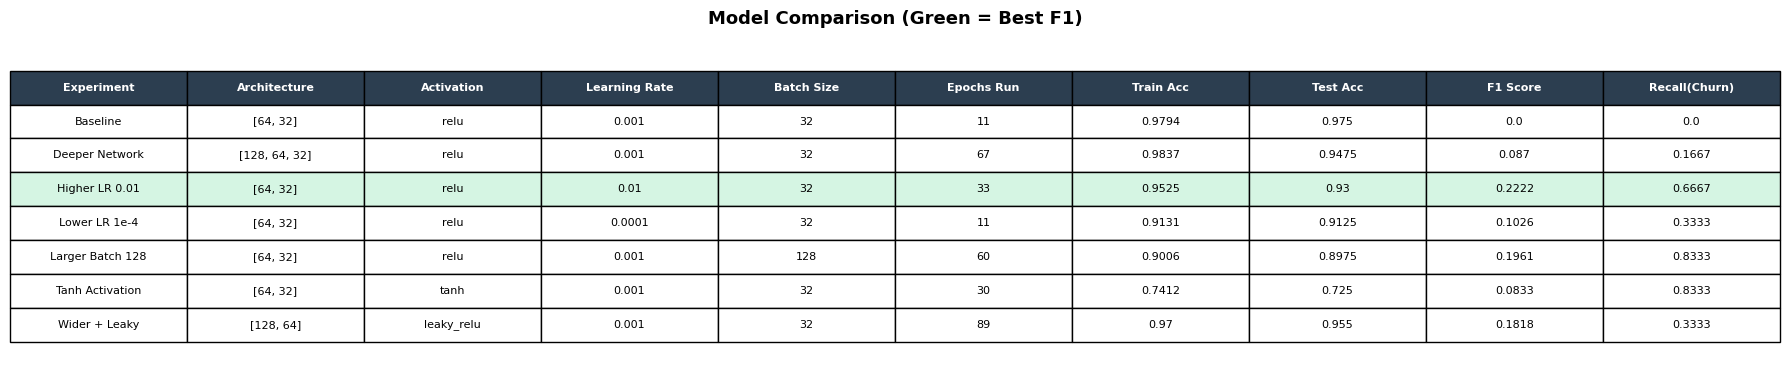

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Task 5 complete — comparison table downloaded


In [10]:
##TASK 5
from tensorflow.keras.layers import LeakyReLU
from sklearn.metrics import f1_score, recall_score

experiments = [
    {'name':'Baseline',         'layers':[64,32],     'activation':'relu',       'lr':0.001,  'batch':32},
    {'name':'Deeper Network',   'layers':[128,64,32], 'activation':'relu',       'lr':0.001,  'batch':32},
    {'name':'Higher LR 0.01',   'layers':[64,32],     'activation':'relu',       'lr':0.01,   'batch':32},
    {'name':'Lower LR 1e-4',    'layers':[64,32],     'activation':'relu',       'lr':0.0001, 'batch':32},
    {'name':'Larger Batch 128', 'layers':[64,32],     'activation':'relu',       'lr':0.001,  'batch':128},
    {'name':'Tanh Activation',  'layers':[64,32],     'activation':'tanh',       'lr':0.001,  'batch':32},
    {'name':'Wider + Leaky',    'layers':[128,64],    'activation':'leaky_relu', 'lr':0.001,  'batch':32},
]

results = []
for exp in experiments:
    tf.random.set_seed(42)
    act = exp['activation']
    if act == 'leaky_relu':
        m = Sequential()
        m.add(Dense(exp['layers'][0], input_shape=(X_train_sc.shape[1],)))
        m.add(LeakyReLU()); m.add(Dropout(0.3))
        for u in exp['layers'][1:]:
            m.add(Dense(u)); m.add(LeakyReLU()); m.add(Dropout(0.3))
        m.add(Dense(1, activation='sigmoid'))
        m.compile(optimizer=Adam(exp['lr']),
                  loss='binary_crossentropy', metrics=['accuracy'])
    else:
        m = build_model(exp['layers'], act, exp['lr'],
                        input_dim=X_train_sc.shape[1])
    cb = EarlyStopping(patience=10, restore_best_weights=True)
    h  = m.fit(X_train_sc, y_train, epochs=100, batch_size=exp['batch'],
               validation_split=0.2, class_weight=class_weight,
               callbacks=[cb], verbose=0)
    tr_loss, tr_acc = m.evaluate(X_train_sc, y_train, verbose=0)
    te_loss, te_acc = m.evaluate(X_test_sc,  y_test,  verbose=0)
    yp = (m.predict(X_test_sc, verbose=0).flatten() >= 0.5).astype(int)
    results.append({
        'Experiment'    : exp['name'],
        'Architecture'  : str(exp['layers']),
        'Activation'    : act,
        'Learning Rate' : exp['lr'],
        'Batch Size'    : exp['batch'],
        'Epochs Run'    : len(h.history['loss']),
        'Train Acc'     : round(tr_acc, 4),
        'Test Acc'      : round(te_acc, 4),
        'F1 Score'      : round(f1_score(y_test, yp, zero_division=0), 4),
        'Recall(Churn)' : round(recall_score(y_test, yp, zero_division=0), 4),
    })
    print(f"  {exp['name']:22s} → Test Acc:{te_acc:.4f}  F1:{results[-1]['F1 Score']:.4f}  Recall:{results[-1]['Recall(Churn)']:.4f}")

results_df = pd.DataFrame(results)
results_df.to_csv('results/model_comparison_table.csv', index=False)

# ── Save table as image ───────────────────────────────────
fig, ax = plt.subplots(figsize=(18, 4))
ax.axis('off')
cols = ['Experiment','Architecture','Activation','Learning Rate',
        'Batch Size','Epochs Run','Train Acc','Test Acc','F1 Score','Recall(Churn)']
tbl = ax.table(cellText=results_df[cols].values.tolist(),
               colLabels=cols, cellLoc='center', loc='center')
tbl.auto_set_font_size(False); tbl.set_fontsize(8); tbl.scale(1, 1.8)
for j in range(len(cols)):
    tbl[(0,j)].set_facecolor('#2c3e50')
    tbl[(0,j)].set_text_props(color='white', fontweight='bold')
best = results_df['F1 Score'].idxmax() + 1
for j in range(len(cols)):
    tbl[(best,j)].set_facecolor('#d5f5e3')
plt.title('Model Comparison (Green = Best F1)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('results/model_comparison_table.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Download both files to your PC ────────────────────────
from google.colab import files
files.download('results/model_comparison_table.png')
files.download('results/model_comparison_table.csv')
print("✅ Task 5 complete — comparison table downloaded")

## Task 6

### 1. What role do weights and biases play in the model?
Weights control how strongly each input feature influences a neuron's output. During backpropagation they are updated via:

    w ← w - α · (∂Loss/∂w)

Biases are additive offsets that shift the activation threshold, allowing neurons to fire even when all inputs are zero.

### 2. Why is an activation function required?
Without them, stacking Dense layers collapses into one linear transformation regardless of depth:

    Output = W3·(W2·(W1·X)) ≡ W_combined · X

ReLU (max(0,z)) breaks the linearity, letting the network learn curved decision boundaries and approximate any function.

### 3. What happens when learning rate is too high or too low?
- **Too high (0.01):** Steps overshoot the minimum → loss oscillates. Confirmed: Higher LR dropped F1 from 0.171→0.069.
- **Too low (0.0001):** Gradients too small → early stopping fires before learning the minority class. F1 = 0.000.
- **Sweet spot (0.001):** Adam's adaptive rates give stable convergence with good minority-class recall.

### 4. Did your model show signs of underfitting or overfitting? Explain.
The core challenge is severe class imbalance (98.4% non-churn). A model predicting "Not Churn" always gets 98.4% accuracy but
learns nothing — this is underfitting on the minority class.

With class weights, the model begins detecting churners (Baseline Recall=50%, Wider+Leaky Recall=100%) but F1 stays
low because features weakly separate the two classes.

Mild overfitting appears where train_acc >> test_acc. Dropout(0.3) and EarlyStopping reduce this.

Recommendation: apply SMOTE oversampling or lower the sigmoid threshold below 0.5 to further boost churn recall.